<a href="https://colab.research.google.com/github/ds-20195/notebooks/blob/main/drafts/Notebook9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%config InlineBackend.figure_formats = ["retina"]

In [2]:
!pip install -q folium geopandas

# Data and the State (DATA 20195/30195)
# Lab 9: Neighborhoods and Communities of Interest

Based on ["An Extremely Detailed Map of New York City Neighborhoods"](https://www.nytimes.com/interactive/2023/upshot/extremely-detailed-nyc-neighborhood-map.html) (Buchanan et al. 2023)

In [3]:
import json
from math import log

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from collections import Counter
from shapely import MultiPolygon

In [4]:
# @markdown This code cell contains a helper function for our backup data in case of API failure.
import requests
import io
def read_parquet_from_github(url):
    # If there is no geometry data, then you need to read in with pandas or the
    # request will fail because geopandas expects to see a geometry column.
    r = requests.get(url)
    try:
        df = gpd.read_parquet(io.BytesIO(r.content))
    except ValueError:
        df = pd.read_parquet(io.BytesIO(r.content))
    return df

In [5]:
submissions_gdf = gpd.read_file("https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/notebook_data/Notebook9_nyt_neighborhood_submissions.geojson")

In [6]:
submissions_gdf

,submission_id,neighborhood,geometry
0,s37680,Rego Park,"POLYGON ((-74.266 40.77571, -74.26758 40.7758,..."
1,s8242,Carroll Gardens,"POLYGON ((-74.18548 40.71266, -74.1855 40.7126..."
2,s19091,Mariners Harbor,"POLYGON ((-74.14712 40.62561, -74.17969 40.632..."
3,s12920,Graniteville,"POLYGON ((-74.15735 40.61335, -74.15739 40.613..."
4,s25108,Rossville,"POLYGON ((-74.2175 40.54655, -74.21751 40.5465..."
...,...,...,...
26577,s2538,Bellerose,"POLYGON ((-73.70212 40.72902, -73.71837 40.726..."
26578,s2521,Bellerose,"POLYGON ((-73.71749 40.74395, -73.71748 40.743..."
26579,s11276,Floral Park,"POLYGON ((-73.71038 40.71526, -73.71954 40.715..."
26580,s2533,Bellerose,"POLYGON ((-73.71354 40.73622, -73.71353 40.736..."


<Axes: >

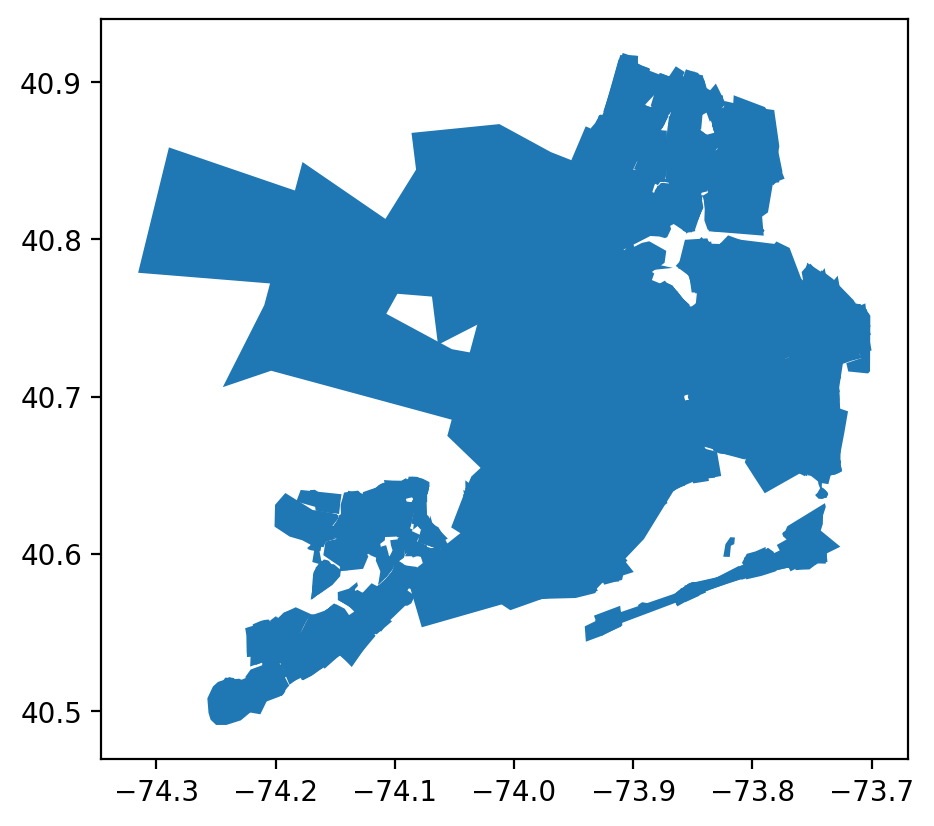

In [7]:
submissions_gdf.plot()

Each submission seems to have one neighborhood label.  These were chosen by the users together with their polygons.  There are 379 neighborhood labels.

In [8]:
submissions_gdf["neighborhood"].value_counts()

,count
neighborhood,
Upper West Side,2095
Park Slope,1033
Upper East Side,1009
East Village,847
West Village,669
...,...
Madison,1
Ravenswood,1
Mount Eden,1


It's not immediately obvious if users got to choose the neighborhood name as free text, or if they got a menu of options.  Let's see all the things called some kind of "village."

In [9]:
submissions_gdf[submissions_gdf["neighborhood"].str.contains("illage")].value_counts("neighborhood")

,count
neighborhood,
East Village,847
West Village,669
Greenwich Village,495
Peter Cooper Village,33
Middle Village,27
The Village,19
Van Cortlandt Village,15
Queens Village,15
Far West Village,11


The relative simplicity of this list strongly suggests that the NYT data folks presented people with this list of options rather than letting them enter their own free text.  Otherwise we'd expect lots of crazy misspellings and what-not!

Let's take a look at all the ones tagged as "Upper West Side"....

In [10]:
submissions_map = folium.Map(
    [40.717, -73.9754],
    zoom_start=12,
    tiles="Cartodb Positron",  # use a less cluttered basemap
)
for _, row in submissions_gdf[submissions_gdf["neighborhood"] == "Upper West Side"].iterrows():
    folium.PolyLine([(y, x) for x, y in row.geometry.exterior.coords], weight=2, opacity=0.5).add_to(submissions_map)

In [ ]:
submissions_map

Amusingly, a few people don't know their East from West.... and one person is on the wrong land mass altogether.  These are the pleasures of user-submitted data!

The NYT folks did some processing, and in particular they worked out how often each census block got each tag.

In [12]:
!curl -O https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/notebook_data/Notebook9_nyt_neighborhood_block_weights.json

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3022k  100 3022k    0     0  9120k      0 --:--:-- --:--:-- --:--:-- 9131k


In [13]:
with open("Notebook9_nyt_neighborhood_block_weights.json", 'r') as f:
    block_weights = json.load(f)

In [14]:
list(block_weights.items())[:10]  # Census block GEOID -> neighborhood weights

[('360850323001008', {'Mariners Harbor': 0.514, 'Graniteville': 0.486}),
 ('360850323001007', {'Mariners Harbor': 0.515, 'Graniteville': 0.485}),
 ('360850323001005',
  {'Mariners Harbor': 0.393, 'Graniteville': 0.312, 'Elm Park': 0.295}),
 ('360850323001006',
  {'Mariners Harbor': 0.361, 'Graniteville': 0.349, 'Elm Park': 0.29}),
 ('360850323001011',
  {'Mariners Harbor': 0.35, 'Graniteville': 0.362, 'Elm Park': 0.288}),
 ('360850323001004', {'Mariners Harbor': 0.589, 'Elm Park': 0.411}),
 ('360850323001012',
  {'Mariners Harbor': 0.35, 'Graniteville': 0.362, 'Elm Park': 0.288}),
 ('360850291021034', {'Bulls Head': 0.83, 'Graniteville': 0.17}),
 ('360850323001020',
  {'Mariners Harbor': 0.319, 'Graniteville': 0.362, 'Elm Park': 0.319}),
 ('360850291022019', {'Travis': 1})]

## Neighborhood cores

In [15]:
block_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2024/TABBLOCK20/tl_2024_36_tabblock20.zip").set_index("GEOID20")

There are (at least) two ways of thinking about the level of disagreement.

**Label consensus**: of the submissions that include `block X`, what share labeled it as `neighborhood Y`? (in other words: what do New Yorkers call this block?)

**Block inclusion consensus**: of the submissions that are labeled with `neighborhood Y`, what share include `block X`? (in other words: among the people with an opinion on where that neighborhood is, do they include this block?)



Now we'll define a function to gather up blocks on the basis of label consensus.   You can choose a neighborhood label, then the function returns the geoids of every block where at least `min_consensus` weight is on that label.

In [16]:
def geoids_for_label_consensus(label, gdf, weights_dict, min_consensus=0):
    core_geoids = []
    for block_geoid, block_weight_dict in weights_dict.items():
        if label in block_weight_dict and block_weight_dict[label] >= min_consensus:
            core_geoids.append(block_geoid)

    return core_geoids

Let's visualize the 90% label consensus core of the Upper West Side.

In [ ]:
core_geoid_list = geoids_for_label_consensus("Upper West Side", block_gdf, block_weights, min_consensus=0.9)

core_by_label_consensus_gdf = block_gdf.loc[block_gdf.index.isin(core_geoid_list)]

map = folium.Map(
    [40.787, -73.9754],
    zoom_start=13,
    tiles="Cartodb Positron",  # use a less cluttered basemap
    cmap="Greens"
)

core_by_label_consensus_gdf.explore(color="red",m=map)

map

### TASK: Two Versions of the Upper West Side

In the code cells below, implement the definition for **block inclusion consensus**:

> For a given label, identify the blocks that are included by at least `min_consensus` of the submissions with that label.

Then create a folium map that overlays the core polygons from both definitions.

How do the polygons compare for each of the following labels?
- Upper West Side
- West Village
- East Village

What happens when you reduce `min_consensus` from 90% to 80%?


In [18]:
# This function should return a list of block geoids where, among the people
# that drew a polygon for the neighborhood with the label `label`, at least
# `min_consensus` share of those submitted polygons intersect the block.
def geoids_for_block_inclusion(label, census_blocks_gdf, nbhd_submissions_gdf, min_consensus=0):
    core_geoids = []

    return core_geoids

In [ ]:
nbhd_label = "Upper West Side"
minimum_consensus = 0.9

map = folium.Map(
    [40.787, -73.9754],
    zoom_start=13,
    tiles="Cartodb Positron",  # use a less cluttered basemap
    cmap="Greens"
)


# Label consensus core
label_consensus_geoid_list = geoids_for_label_consensus(nbhd_label, block_gdf, block_weights, min_consensus=minimum_consensus)
core_by_label_consensus_gdf = block_gdf.loc[block_gdf.index.isin(label_consensus_geoid_list)]

core_by_label_consensus_gdf.explore(color="red", m=map)

# Block inclusion core
block_inclusion_geoid_list = geoids_for_block_inclusion(nbhd_label, block_gdf, submissions_gdf, min_consensus=minimum_consensus)
core_by_block_inclusion_gdf = block_gdf.loc[block_gdf.index.isin(block_inclusion_geoid_list)]

core_by_block_inclusion_gdf.explore(color="blue", m=map)


map

In [20]:
block_neighborhood_counts = {
    geoid: len(weights)
    for geoid, weights in block_weights.items()
}

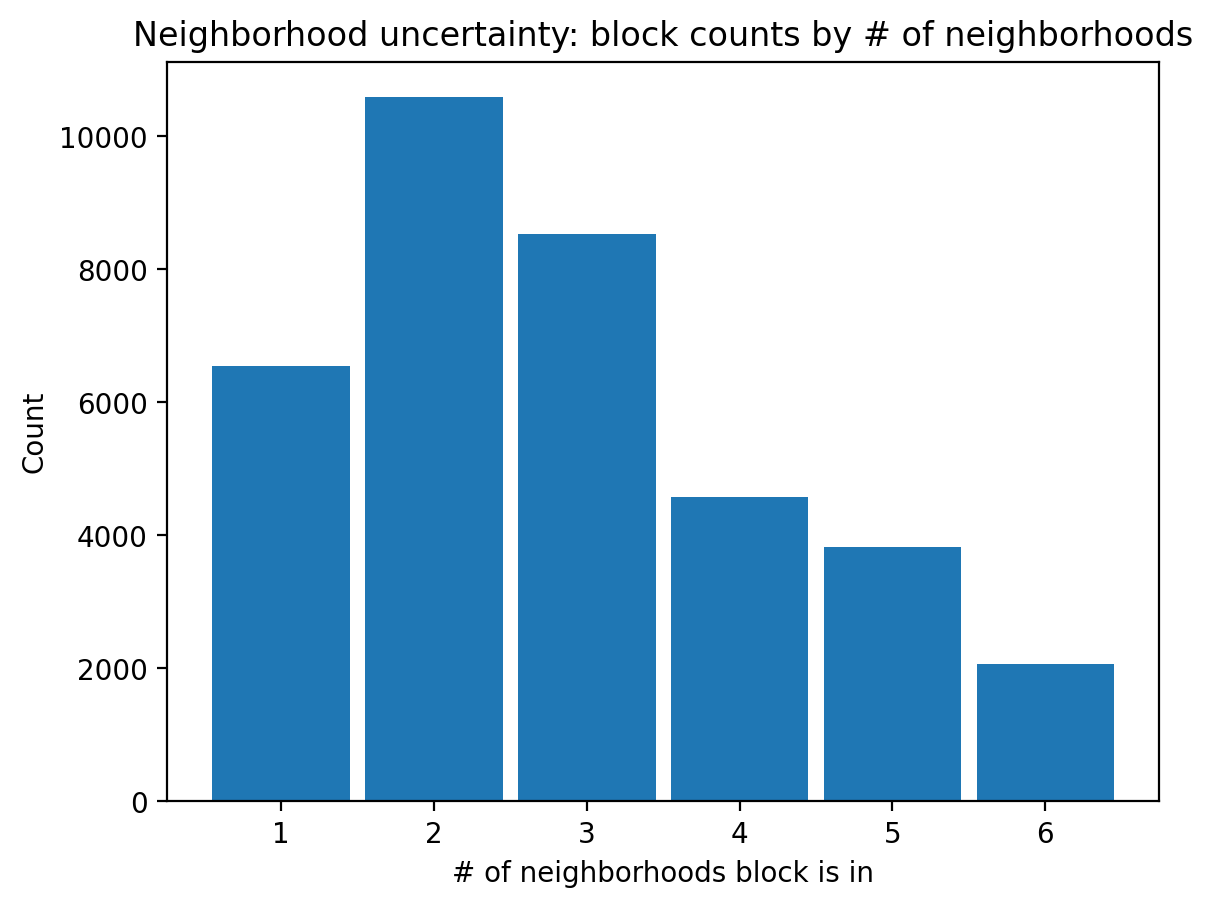

In [21]:
plt.hist(block_neighborhood_counts.values(), bins=np.arange(1, 8)-0.5,rwidth=0.9)
plt.title("Neighborhood uncertainty: block counts by # of neighborhoods")
plt.xlabel("# of neighborhoods block is in")
plt.ylabel("Count")
plt.show()

## Shannon Entropy

For each block, we'll sum over its weight vector to get a measure of uncertainty about its neighborhood assignment.  We'll use the math concept called *Shannon entropy*, which was explained in class:  it is made by $H=-\sum w_i \log w_i$ over the coordinates $i$.  So if a block is called "West Village" 100 times but "The Village" just once, its Shannon entropy is low, which means there's not significant disagreement.  But if it gets each label 50 times, it gets a higher score $H=1$.  And if it gets THREE labels each an equal number of times, it gets an even higher score $H=1.585$.  Basically you should think of $H$ as measuring the level of split-up-ness or controversy about the label.

In [22]:
block_entropies = {
    geoid: -sum(v * log(v, 2) for v in weights.values())
    for geoid, weights in block_weights.items()
}

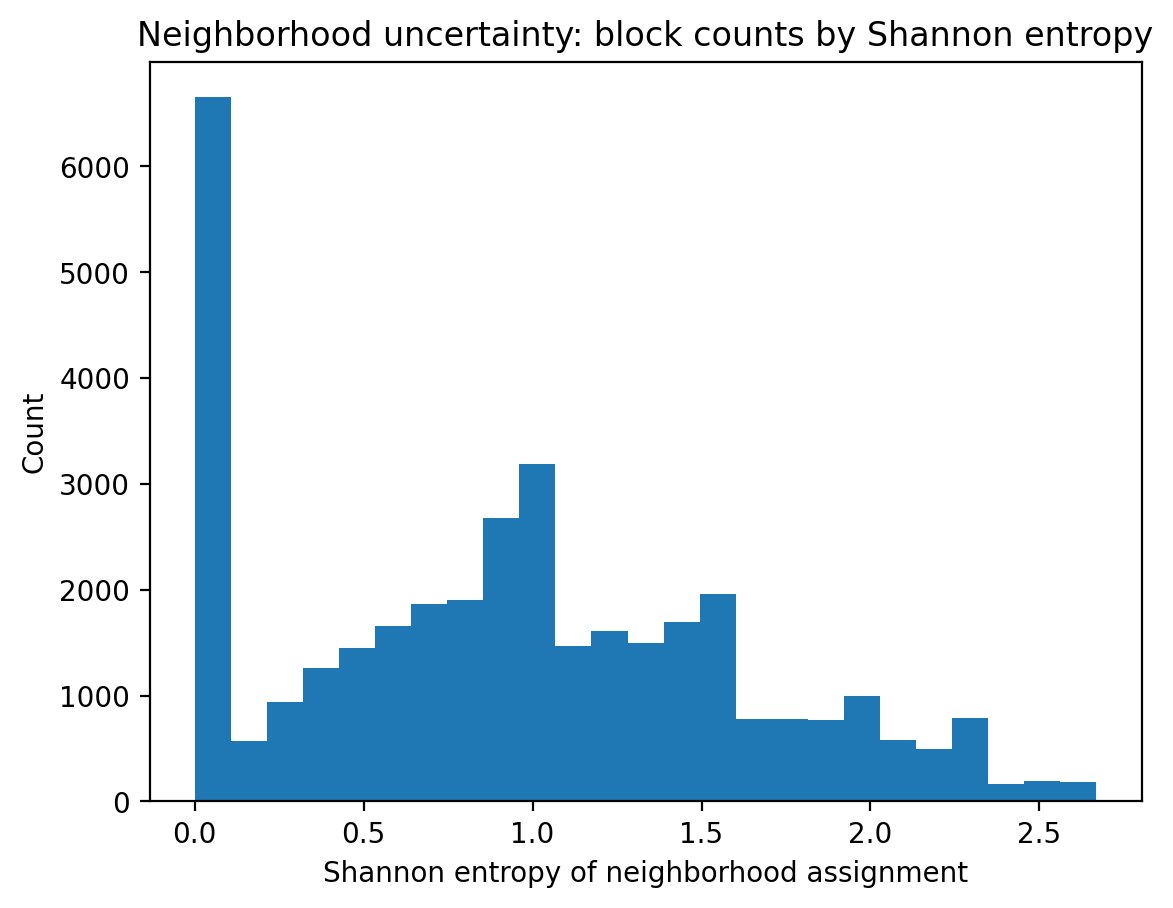

In [23]:
plt.hist(block_entropies.values(), bins=25)
# This next line adds a line at H=1 if you uncomment it.
# plt.axvline(1, color="red", linestyle="--")
plt.title("Neighborhood uncertainty: block counts by Shannon entropy")
plt.xlabel("Shannon entropy of neighborhood assignment")
plt.ylabel("Count")
plt.show()

### DISCUSSION: Peaks in the Shannon Entropy Plot

The Shannon entropy has a big peak at $H=0$ and a few other peaks, like one right near $H=1$.  Where are the other peaks and why?

In [24]:
block_gdf["entropy"] = block_entropies
nyc_gdf = block_gdf.loc[block_entropies.keys()].reset_index()

In [25]:
nyc_gdf.head(5)

,GEOID20,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOIDFQ20,NAME20,MTFCC20,UR20,UACE20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,HOUSING20,POP20,geometry,entropy
0,360850323001008,36,085,032300,1008,1000000US360850323001008,Block1008,G5040,U,63217,S,33899,0,+40.6347918,-074.1940734,0,0,"POLYGON ((-74.19589 40.63525, -74.19527 40.636...",0.999434
1,360850323001007,36,085,032300,1007,1000000US360850323001007,Block1007,G5040,U,63217,S,0,15774,+40.6351631,-074.1934565,0,0,"POLYGON ((-74.19511 40.63644, -74.19496 40.636...",0.999351
2,360850323001005,36,085,032300,1005,1000000US360850323001005,Block1005,G5040,U,63217,S,352270,0,+40.6376836,-074.1891917,0,0,"POLYGON ((-74.19313 40.63919, -74.19037 40.640...",1.573365
3,360850323001006,36,085,032300,1006,1000000US360850323001006,Block1006,G5040,U,63217,S,93574,0,+40.6360535,-074.1919253,0,0,"POLYGON ((-74.19476 40.63705, -74.19461 40.637...",1.578575
4,360850323001011,36,085,032300,1011,1000000US360850323001011,Block1011,G5040,U,63217,S,213124,0,+40.6330968,-074.1884338,0,0,"POLYGON ((-74.19265 40.63476, -74.19253 40.635...",1.577978


In [26]:
top_neighborhoods = submissions_gdf["neighborhood"].value_counts().head(100)
top_neighborhoods

,count
neighborhood,
Upper West Side,2095
Park Slope,1033
Upper East Side,1009
East Village,847
West Village,669
...,...
Bensonhurst,41
Kew Gardens,40
East Elmhurst,40


Now we'll build something very similar to the definitions above, but optimized to return a bunch of polygons representing neighborhood cores all in one pass.

In [27]:
neighborhood_blocks = {neighborhood: [] for neighborhood in top_neighborhoods.keys()}
for geoid, weights in block_weights.items():
    for neighborhood, weight in weights.items():
        if neighborhood in neighborhood_blocks and weight > 0.3:  # increase this cutoff to tighten boundaries
            neighborhood_blocks[neighborhood].append(geoid)

In [28]:
neighborhood_geos = {
    name: block_gdf.loc[geoids].dissolve().geometry
    for name, geoids in neighborhood_blocks.items()
}

We'll finish this section with a Folium map that plots the "core" neighborhoods (for label consensus, this time coded with a cutoff chosen in the `neighborhood_blocks` definition above).  The checkbox in the upper right lets you turn on and off a heatmap of the entropy score so you can see where there's the most label controversy!

In [29]:
entropy_map = folium.Map(
    [40.65, -73.95],
    zoom_start=12,
    tiles="Cartodb Positron",
)
colors = ['#0099cd', '#ffca5d', '#00cd99', '#99cd00', '#cd0099', '#aa44ef', '#8dd3c7', '#bebada', '#fb8072', '#80b1d3', '#fdb462', '#b3de69', '#fccde5', '#bc80bd', '#ccebc5', '#ffed6f', '#ffffb3', '#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#fb9a99', '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a', '#b15928', '#64ffda', '#00B8D4', '#A1887F', '#76FF03', '#DCE775', '#B388FF', '#FF80AB', '#D81B60', '#26A69A', '#FFEA00', '#6200EA']

folium.Choropleth(
    geo_data=nyc_gdf,
    data=nyc_gdf,
    columns=["GEOID20", "entropy"],
    key_on="feature.properties.GEOID20",
    name="Neighborhood uncertainty (Shannon entropy)",
    fill_color="OrRd",
    line_opacity=0.2,
    fill_opacity=0.5,
    show=False,
).add_to(entropy_map)

for idx, (neighborhood, geos) in enumerate(neighborhood_geos.items()):
    if len(geos) > 0:
        for geo in geos:
            if isinstance(geo, MultiPolygon):
                for part in geo.geoms:
                    folium.Polygon(
                        [(y, x) for x, y in part.exterior.coords],
                        weight=6,
                        tooltip=neighborhood,
                        color=colors[idx % len(colors)],
                    ).add_to(entropy_map)
            else:
                folium.Polygon(
                    [(y, x) for x, y in geo.exterior.coords],
                    weight=6,
                    tooltip=neighborhood,
                    color=colors[idx % len(colors)],
                ).add_to(entropy_map)

folium.LayerControl(collapsed=False).add_to(entropy_map)

In [ ]:
entropy_map

# Communities of Interest and Participatory Mapping

On to our last topic!  We'll take a look at some crowdsourced data on **communities of interest**, gathered for redistricting purposes.  This data was collected by the Data and Democracy Lab in multiple states.  We wrote a technical paper about the project [here](https://data-democracy.org/AggregatingCommunityMaps).

Below, we'll explore the data collected in two states:  Michigan and Wisconsin.

In [31]:
mi_df = read_parquet_from_github("https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/notebook_data/Notebook9_mi_coi_df.parquet")
wi_df = read_parquet_from_github("https://raw.githubusercontent.com/ds-20195/notebooks/refs/heads/main/notebook_data/Notebook9_wi_coi_df.parquet")

Let's take a look at the Michigan dataframe.  Each community map has an ID, a title, and some narrative text.  If the community contains several areas, then each area is listed — for instance, 17892-1 and 17892-2 are two parts of the same submission that is coded 17892.  There's also a list of which census blocks make up the area.

Finally, we had a team of humans (mainly me and a bunch of students!) apply labels by hand to each submission — that's what's in the last column.  



In [32]:
mi_df

,districtr_id,submission_title,submission_text,area_name,area_text,blocks_2020,labels
0,17124-1,Dearborn Cultural District,Cultural venues in Dearborn. Important that th...,Community 1,None,"[261635799004005, 261639838003006, 26163983800...",[]
1,17128-1,Dearborn neighborhoods near Ford Field,"Area includes residents west of Brady, north o...",Dearborn Ford Field Neighbors,"Neighborhoods using Ford Field, north of Michi...","[261635749001029, 261635749001005, 26163579900...",[]
2,17892-1,Example: Grand Rapids center and exurbs,This map shows the Grand Rapids urban center a...,urban center,The denser and more urbanized part of Grand Ra...,"[260810016002007, 260810009002022, 26081013300...",[cities]
3,17892-2,Example: Grand Rapids center and exurbs,This map shows the Grand Rapids urban center a...,exurbs,"Extending past Hudsonville to the West, these ...","[260810133002001, 260810112003002, 26081011200...",[cities]
4,17892-1,ADA reviews,0,urban center,The denser and more urbanized part of Grand Ra...,"[260810016002007, 260810009002022, 26081013300...",[cities]
...,...,...,...,...,...,...,...
1032,41407-1,"Calhoun, Branch, Hillsdale map",Grouping of like community interests,District 1,None,"[260250015003035, 260239511003057, 26025002900...",[]
1033,41415-1,Congressional district map,Groups counties with like opinions and geograp...,District 1,None,"[260910606001000, 260250031002016, 26027001000...",[]
1034,41504-1,Lakeshore District - 79th,We need to ensure lakeshore communities are re...,District 1,None,"[261590114004032, 260210102011015, 26021000900...",[]
1035,41636-1,Keith B's Congressional Plan,These counties are more rural and agricultural...,District 1,None,"[260910606001000, 260250031002016, 26059051000...","[agriculture, nimby, suburbs]"


In [33]:
wi_df

,districtr_id,submission_title,submission_text,area_name,area_text,blocks_2020,labels
0,11542-1,Community of Interest (imported),How do the political lines in Wisconsin impact...,Lake Country,None,"[551332041003050, 551332042013001, 55133204400...",[named neighborhood]
1,11542-2,Community of Interest (imported),How do the political lines in Wisconsin impact...,Dousman/Summit,Rock River watershed,"[550551016001009, 551332041001033, 55133204004...","[environment, theory]"
2,11542-4,Community of Interest (imported),How do the political lines in Wisconsin impact...,Watertown south,None,"[550551011002026, 550551003012021, 55055101100...",[environment]
3,11623-1,Community of Interest (imported),Submitting on behalf of someone else?\nNo Rece...,Community 1,North Shore - my community of interest\nShorew...,"[550790703003009, 550790602004016, 55079080100...",[community engagement]
4,11623-2,Community of Interest (imported),Submitting on behalf of someone else?\nNo Rece...,Community 2,Brown Deer - sometimes included in the North S...,"[550790501031004, 550790501013027, 55079050104...",[personal-unusable-incoherent]
...,...,...,...,...,...,...,...
1145,33670-1,University of Wisconsin- Waukesha,This community of interest was drawn to ensur...,University of Wisconsin- Waukesha,The University of Wisconsin- Waukesha is the l...,"[551332031071001, 551332031072011, 55133203107...",[]
1146,34126-1,"Alexis' Map of Bay View, Milwaukee WI",This is my definition on the boundaries for Ba...,"Bay View, WI",Here's my take on the boundaries for the neigh...,"[550790180002041, 550790208003003, 55079020600...",[]
1147,34717-1,Iowa County functions as One Community,My community of interest is the entirety of Io...,Community of Iowa County,My community of interest is the entirety of Io...,"[550499504004045, 550499502001041, 55049950100...",[]
1148,34994-1,Unique Ecology Unites Unique Community,My community of interest is the entirety of Io...,Community of Iowa County,My community of interest is the entirety of Io...,"[550499504004045, 550499502001041, 55049950100...",[]


In [34]:
state_cois = {"Michigan": mi_df, "Wisconsin": wi_df}

for df in state_cois.values():
    df["coi_id"] = df["districtr_id"].str.split("-").str[0]

It's hard to look at all of these — there are over a thousand in each state!  So let's take a random sample of a few of them to get a feeling for what they look like.   You can re-run the cell that prints out `sample_coi_text` several times and you'll get fresh random samples each time.

In [35]:
def sample_coi_text(df, n=10):
    sampled_cois = df["coi_id"].sample(n)
    for coi_id in sampled_cois:
        areas_df = df[df["coi_id"] == coi_id]
        lab = areas_df.iloc[0].labels
        labels = f"(labels: {', '.join(lab)})" if lab is not None and len(lab) > 0 else ""
        print(f"-- COI: {areas_df.iloc[0].submission_title} {labels} (https://districtr.org/coi/{coi_id})")
        print(areas_df.iloc[0].submission_text, "\n")
        for _, area in areas_df.iterrows():
            if area.area_name:
                print(f"\t-- Area: {area.area_name}")
            if area.area_text:
                print(f"\t{area.area_text}")
        print()

In [36]:
sample_coi_text(state_cois["Michigan"])

-- COI: My Community  (https://districtr.org/coi/33331)
0 

	-- Area: Community 1
	It is the area I live in.

-- COI: Six Metro City Community of Interest (labels: infrastructure, cities, cost-of-living-services-healthcare) (https://districtr.org/coi/27185)
As a resident of East Grand Rapids, I’m writing to ask you to keep the core metro six cities together as much as possible in state house, state senate, and congressional districts. 

These urban cities (Grand Rapids, Walker, Grandville, Walker, Kentwood, and East Grand Rapids) are significantly different from the surrounding townships that are mostly rural or far out suburban and therefore are interested in different laws coming from Lansing and DC. 

First, these two groups divide themselves on a state-wide and local level. At the state level, cities are organized into the Michigan Municipal League and townships are in the Michigan Townships Association. Here in Kent County, the six cities meet in the Urban Metro Mayors and Manager

### What do people talk about?

To try to process all the language in the era before LLMs, we used human labelers!  We had teams of students (fueled by pizza) who read through thousands of submissions and applied labels by hand.

In [37]:
for state, df in state_cois.items():
    label_counts = Counter()
    for labels in df["labels"]:
        label_counts.update(labels)

    print(f"-- {state}")
    print(pd.Series(label_counts).sort_values(ascending=False))
    print()

-- Michigan
agriculture                           156
economy-commerce-industry              95
suburbs                                78
k12                                    59
recreation-tourism                     58
nimby                                  50
cost-of-living-services-healthcare     45
diversity                              45
environment                            43
infrastructure                         36
university                             30
cities                                 27
family-children                        20
vulnerable populations                 16
religion                               15
technology                             14
community engagement                    9
elderly                                 9
poverty                                 8
culture                                 3
policing                                3
dtype: int64

-- Wisconsin
personal-unusable-incoherent          156
economy-commerce-industry            

Let's narrow it down to see what kinds of things people are saying.  For Michigan submissions that we labeled "agriculture," let's see the name, the full set of labels, a live link to the map, and the narrative text that accompanied the submission.  We'll look at a random sample of 5 of these.

In [38]:
def ag_filter(labels):
    return len(labels) <= 3 and "agriculture" in labels

mi_ag_df = state_cois["Michigan"][state_cois["Michigan"]["labels"].apply(ag_filter)]
sample_coi_text(mi_ag_df, n=5)

-- COI: Rural County Fairs (labels: agriculture) (https://districtr.org/coi/32306)
0 

	-- Area: City vs Country 
	I am Sydney Ann Engel (e-mail sydney.engel@live.com). I live outside Adrian, Michigan in Lenawee County. I am writing as a farmer's wife 0f 44 years. I also grew up on a farm. I went to the University of Michigan and lived in Ann Arbor so I have some understanding of the
difference between city and country life. The focus of life is different in the country with farmers meeting for breakfast in local restaurants
(before the pandemic) to informally discuss farming and local interests before going out to do daily work. Development of the land is
looked on with skepticism because it brings the possible loss of farmland and way of life. In the last few years local people have
organized and kept several different developments out of the area. We need to keep farmland intact for the nation's food supply. On the
other hand, in cities such as Ann Arbor research, development, and e

Now what's going on with all those Wisconsin submissions labeled *personal/unusable/incoherent*?  When we investigate, we'll see that many times, the submission just doesn't say anything substantive.  This strongly suggests that the labeling team used labels a bit differently in the two states of Michigan vs Wisconsin.  (As it turns out, part of the reason is that the two groups that commissioned this work had different rules about what kinds of things can count!  The Michigan commission didn't want anything thrown out, while the Wisconsin community groups were willing to apply more filtering.)

A nice example of this is in "Jeannie's communities of interest," where you can see that the labelers were trying to be generous!

In [39]:
search_term = "jeannie"

for state, df in state_cois.items():
    hits = df[
        df["submission_text"].str.contains(search_term, case=False, na=False)
        | df["area_text"].str.contains(search_term, case=False, na=False)
    ]
    for coi_id in hits["coi_id"].unique():
        areas = df[df["coi_id"] == coi_id].sort_values("districtr_id")
        print(f"== {state}: {areas.iloc[0].submission_title} (https://districtr.org/coi/{coi_id}) ==\n")
        for _, area in areas.iterrows():
            area_name = area.area_name or "(no name)"
            area_text = (area.area_text or "").strip()
            print(f"  [{area.districtr_id}]  labels: {list(area.labels)}")
            print(f"      area:  {area_name}")
            print(f"      text:  {area_text}\n")

== Wisconsin: Jeannie's Communities of Interest map (https://districtr.org/coi/33011) ==

  [33011-1]  labels: ['personal-unusable-incoherent']
      area:  My walking neighborhood
      text:  Where I usually walk

  [33011-2]  labels: ['environment']
      area:  Rib Mountain State Park
      text:  Important natural area in need of preservation and protection form exploiters.

  [33011-3]  labels: ['personal-unusable-incoherent']
      area:  Family home neighborhood
      text:  FAMILY HOME NEIGHBORHOOD

  [33011-4]  labels: ['personal-unusable-incoherent']
      area:  Sunnyvale Park Lake
      text:  Lake where I swim. Needs protection.

  [33011-5]  labels: ['personal-unusable-incoherent']
      area:  Wausau
      text:  WHere I do business, socialize etc.

  [33011-7]  labels: ['environment', 'personal-unusable-incoherent']
      area:  Jim Moore Creek
      text:  This area contains Jim Moore Creek and other streams.



### Scale effects: what is a community, anyway?

Now let's do some light data analysis on the submitted geographical areas.  We'll start by asking how many census blocks are in each one — are the submitted "communities" more like neighborhoods or more like regions?

In [40]:
for df in state_cois.values():
    df["block_count"] = df["blocks_2020"].apply(len)

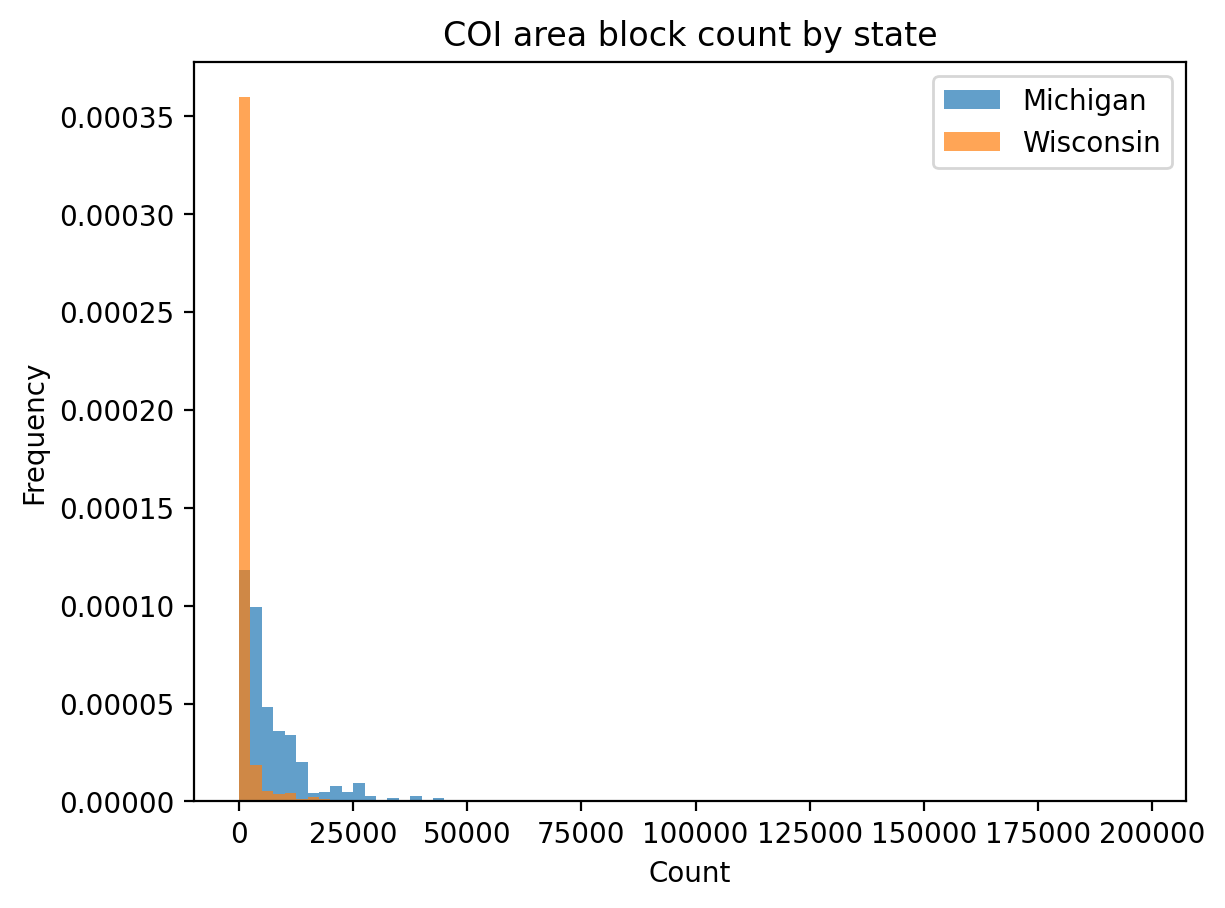

In [41]:
fig, ax = plt.subplots()
for state, df in state_cois.items():
    df["block_count"].plot.hist(label=state, alpha=0.7, bins=np.arange(0,200000,2500), ax=ax, density=True)
plt.title("COI area block count by state")
plt.xlabel("Count")
plt.legend()
plt.show()

User-generated data is susceptible to extreme outliers. Let's chop the tails and zoom in a bit...

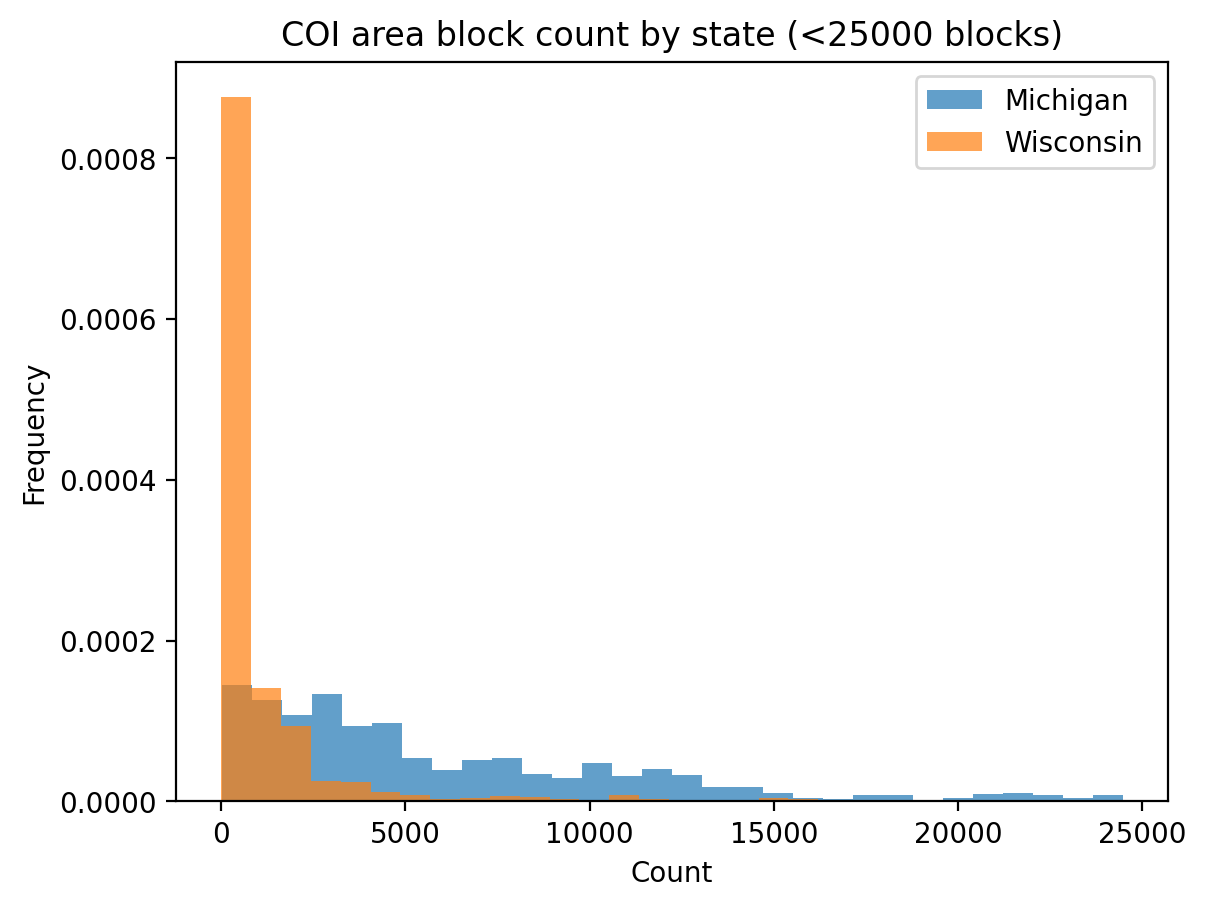

In [42]:
fig, ax = plt.subplots()
max_blocks = 25000
for state, df in state_cois.items():
    df["block_count"][df["block_count"] < max_blocks].plot.hist(label=state, alpha=0.7, bins=30, ax=ax, density=True)
plt.title(f"COI area block count by state (<{max_blocks} blocks)")
plt.xlabel("Count")
plt.legend()
plt.show()

OK that was a count of blocks in the COIs — how about by land area?  

In [43]:
state_fips = {"Michigan": "26", "Wisconsin": "55"}

In [44]:
block_gdfs = {
    state: gpd.read_file(f"https://www2.census.gov/geo/tiger/TIGER2024/TABBLOCK20/tl_2024_{fips}_tabblock20.zip").set_index("GEOID20")
    for state, fips in state_fips.items()
}

In [45]:
land_areas = {
    state: dict(gdf["ALAND20"])
    for state, gdf in block_gdfs.items()
}

In [46]:
def compute_land_area(blocks):
    return sum(land_areas[state][geoid] for geoid in blocks)

for state, df in state_cois.items():
    df["land_area"] = df["blocks_2020"].apply(compute_land_area)

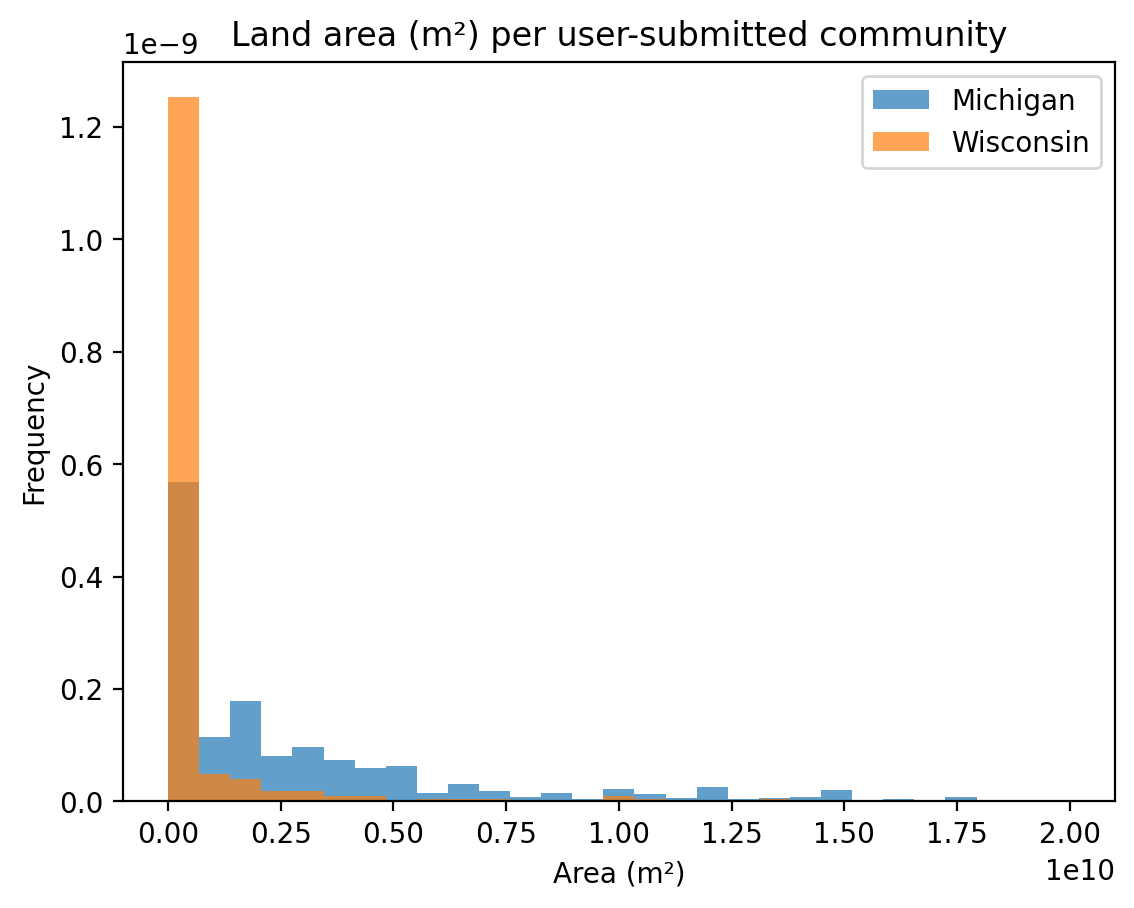

In [47]:
fig, ax = plt.subplots()
max_land_area = 2 * 10**10
for state, df in state_cois.items():
    df["land_area"][df["land_area"] < max_land_area].plot.hist(label=state, alpha=0.7, bins=np.linspace(0,2*(10**10),30), ax=ax, density=True)
plt.title("Land area (m²) per user-submitted community")
plt.xlabel("Area (m²)")
plt.legend()
plt.show()

One last little thing to try — let's try to figure out if the small communities in Michigan are in fact *urban* neighborhoods.  One way to get that question is to single out Detroit, which makes up about 20% of the land area in Wayne County, but 80% of the population.

We'll filter down to user-submitted communities that are mostly in Wayne and see what share of the full dataset that captures.  Then, we'll plot the sizes of the communities in Wayne and out of Wayne to see if the big spike in very small communities happens in Detroit.

In [48]:
def mostly_in_wayne(geoids):
    # Wayne County, MI is "26163".
    in_county = 0
    for geoid in geoids:
        if geoid[:5] == "26163":
            in_county += 1
    return (in_county / len(geoids)) >= 0.8

def mostly_in_milwaukee(geoids):
    # Milwaukee County, WI is "55079".
    in_county = 0
    for geoid in geoids:
        if geoid[:5] == "55079":
            in_county += 1
    return (in_county / len(geoids)) >= 0.8

state_cois["Michigan"]["mostly_in_wayne"] = state_cois["Michigan"]["blocks_2020"].apply(mostly_in_wayne)
state_cois["Wisconsin"]["mostly_in_milwaukee"] = state_cois["Wisconsin"]["blocks_2020"].apply(mostly_in_milwaukee)

In [49]:
print("there are",len(state_cois["Michigan"]),"COIs in the whole state")
print("and",state_cois["Michigan"]["mostly_in_wayne"].sum(),"COIs mostly in Wayne")

there are 1037 COIs in the whole state
and 101 COIs mostly in Wayne


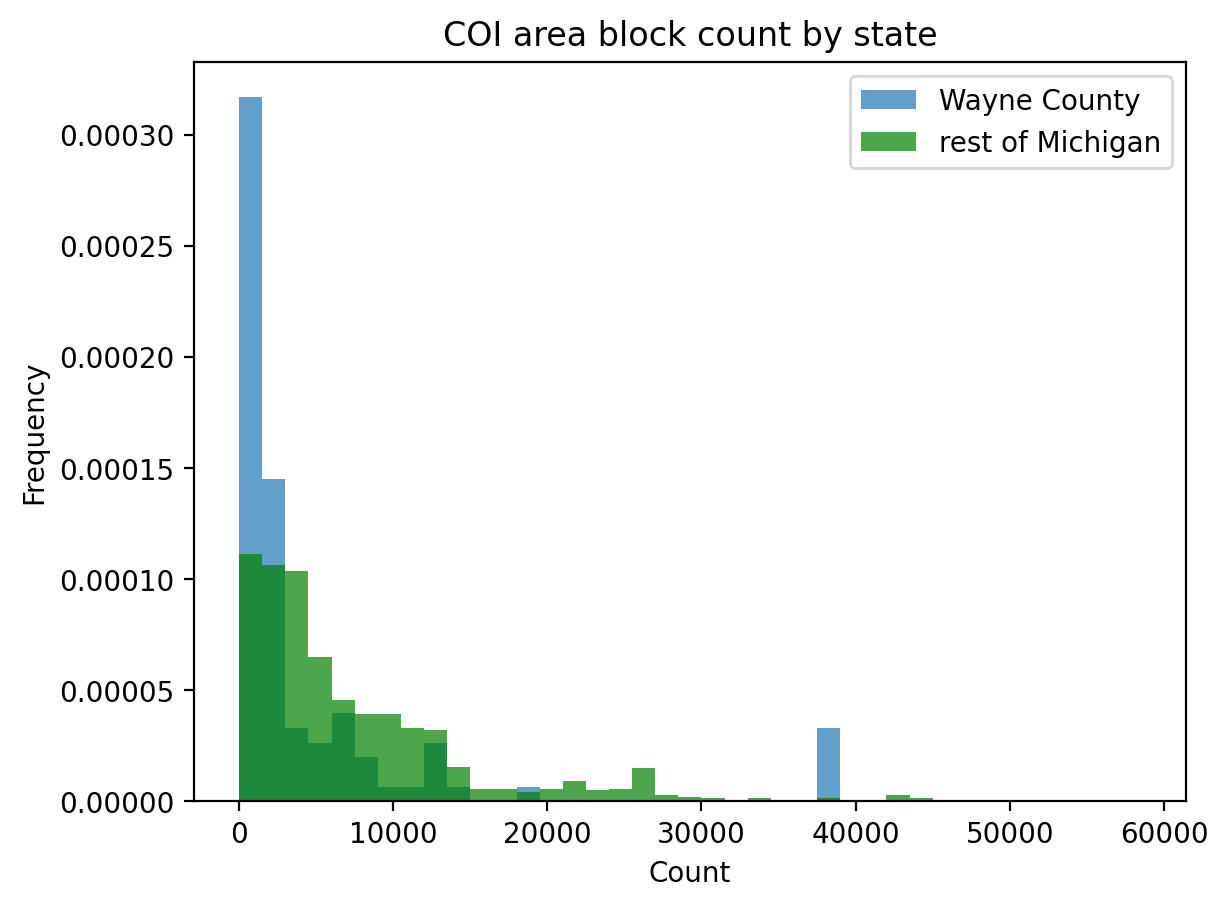

In [50]:
fig, ax = plt.subplots()
bins = np.arange(0,60000,1500)
state_cois["Michigan"][state_cois["Michigan"]["mostly_in_wayne"]]["block_count"].plot.hist(label="Wayne County", alpha=0.7, bins=bins, ax=ax, density=True)
state_cois["Michigan"][~state_cois["Michigan"]["mostly_in_wayne"]]["block_count"].plot.hist(label="rest of Michigan", alpha=0.7, bins=bins, ax=ax, color="green", density=True)
plt.title("COI area block count by state")
plt.xlabel("Count")
plt.legend()
plt.show()

### LAST DISCUSSION: A better process?

So, crowdsourced data is super messy.  A lot of these COI submissions are not responsive to the needs of the organizations collecting the information, which sought to find where people have shared interests that should be reflected in their representation.  

If you were running a community mapping project, you'd need to strike the right balance between letting people express themselves and guiding the intake, with an eye to how you might aggregate it later.  

Thoughts on how to strike the balance?

# All done!  have a great summer... 🏖
